# CVAE — Flip Rate & Confidence Change

Evaluates CVAE-generated counterfactuals using CheXNet as a fixed arbiter.

**Metrics computed separately for each translation direction:**
- **Flip Rate**: fraction of images where CheXNet changes its predicted class after translation
- **Confidence Change (Δ)**: P(pneumonia | counterfactual) − P(pneumonia | original)

**Matching strategy:** CVAE images are indexed sequentially (`img_000000.png`, …).
`counterfactual_labels.csv` maps each `image_index` to its translation direction,
and the original is loaded from `test_dataset.pt[image_index]`.

## 0. Path configuration

In [53]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "utils"))

CVAE_TEST_DIR = PROJECT_ROOT / "synthetic" / "counterfactuals-cvae" / "test"
ORIG_DIR      = CVAE_TEST_DIR / "original"
LABELS_CSV    = CVAE_TEST_DIR / "counterfactual_labels.csv"
CHEXNET_CKPT  = PROJECT_ROOT / "models" / "Classifier" / "chexnet.pth.tar"
RESULTS_DIR   = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print("Counterfactuals :", len(list(CVAE_TEST_DIR.glob("img_*_counterfactual.png"))))
print("Originals       :", len(list(ORIG_DIR.glob("*.png"))))
print("Labels CSV      :", LABELS_CSV.exists())

Counterfactuals : 9021
Originals       : 9021
Labels CSV      : True


## 1. Load CheXNet (fixed arbiter)

In [54]:
import torch
from models.Classifier.classifier import CheXNet
from device import get_device

DEVICE = get_device()
chexnet = CheXNet(CHEXNET_CKPT).to(DEVICE)
print(f"CheXNet loaded on {DEVICE} | eval={not chexnet.training} | trainable params=0")

CheXNet loaded on mps | eval=True | trainable params=0


## 2. Load metadata

`counterfactual_labels.csv` has one row per counterfactual image with columns:
`image_index`, `original_image`, `original_label`, `counterfactual_image`, `counterfactual_label`.

Original images are in `synthetic/counterfactuals-cvae/test/original/` and synthetic
counterfactuals are in `synthetic/counterfactuals-cvae/test/`, so no external download needed.

In [55]:
import pandas as pd

labels_df = pd.read_csv(LABELS_CSV)
labels_df["image_index"] = labels_df["image_index"].astype(int)

print(f"Counterfactual pairs : {len(labels_df)}")
print()
print(labels_df[["original_label", "counterfactual_label"]].value_counts())
print()
labels_df.head()

Counterfactual pairs : 9021

original_label  counterfactual_label
healthy         pneumonia               8978
pneumonia       healthy                   43
Name: count, dtype: int64



,image_index,original_image,original_label_id,original_label,counterfactual_image,counterfactual_label_id,counterfactual_label
0,0,img_000000_original.png,1,pneumonia,img_000000_counterfactual.png,0,healthy
1,1,img_000001_original.png,1,pneumonia,img_000001_counterfactual.png,0,healthy
2,2,img_000002_original.png,1,pneumonia,img_000002_counterfactual.png,0,healthy
3,3,img_000003_original.png,1,pneumonia,img_000003_counterfactual.png,0,healthy
4,4,img_000004_original.png,1,pneumonia,img_000004_counterfactual.png,0,healthy


## 3. Build evaluation pairs

In [56]:
h2p_rows = labels_df[labels_df["original_label"] == "healthy"].copy()
p2h_rows = labels_df[labels_df["original_label"] == "pneumonia"].copy()

def build_pairs(rows: pd.DataFrame) -> list:
    """Return list of (orig_path, synth_path) for rows whose files exist."""
    pairs, missing = [], 0
    for _, row in rows.iterrows():
        orig_path  = ORIG_DIR      / row["original_image"]
        synth_path = CVAE_TEST_DIR / row["counterfactual_image"]
        if orig_path.exists() and synth_path.exists():
            pairs.append((orig_path, synth_path))
        else:
            missing += 1
    if missing:
        print(f"  {missing} pairs with missing files")
    return pairs

h2p_pairs = build_pairs(h2p_rows)
p2h_pairs = build_pairs(p2h_rows)

print(f"H→P usable pairs: {len(h2p_pairs)}")
print(f"P→H usable pairs: {len(p2h_pairs)}")

H→P usable pairs: 8978
P→H usable pairs: 43


## 4. Helper functions

In [57]:
from PIL import Image
from torchvision import transforms
import torch

resize_224 = transforms.Resize((224, 224), antialias=True)
to_tensor  = transforms.ToTensor()

def image_tensor(path: Path) -> torch.Tensor:
    """Load a PNG → (1, 1, 224, 224) float32 in [0, 1]."""
    img = Image.open(path).convert("L")
    return resize_224(to_tensor(img)).unsqueeze(0)

@torch.inference_mode()
def score(tensor: torch.Tensor) -> float:
    """P(pneumonia) for a single (1, 1, 224, 224) tensor."""
    return chexnet.predict_pneumonia(tensor.to(DEVICE)).item()

# Smoke test
test_img = image_tensor(next(ORIG_DIR.glob("*.png")))
print(f"Tensor shape: {test_img.shape}  range: [{test_img.min():.3f}, {test_img.max():.3f}]")

Tensor shape: torch.Size([1, 1, 224, 224])  range: [0.000, 0.922]


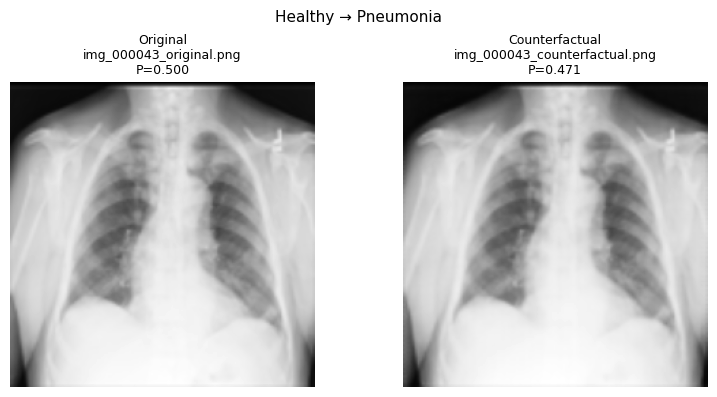

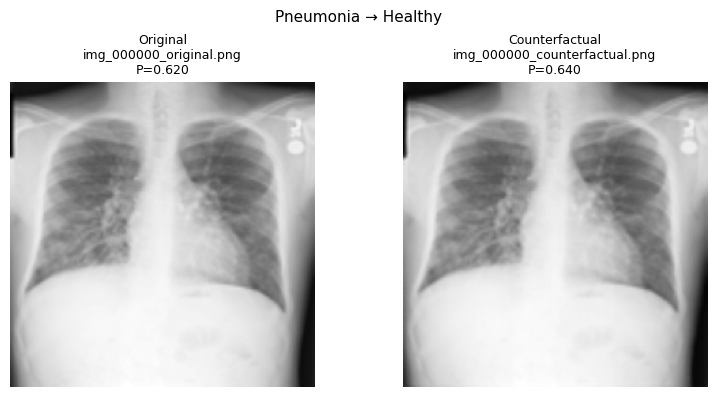

In [58]:
import matplotlib.pyplot as plt

def show_pair(orig_path: Path, synth_path: Path, title: str = ""):
    orig_t = image_tensor(orig_path)
    synt_t = image_tensor(synth_path)

    p_o = score(orig_t)
    p_s = score(synt_t)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(title, fontsize=11)

    axes[0].imshow(orig_t.squeeze().cpu(), cmap="gray")
    axes[0].set_title(f"Original\n{orig_path.name}\nP={p_o:.3f}", fontsize=9)
    axes[0].axis("off")

    axes[1].imshow(synt_t.squeeze().cpu(), cmap="gray")
    axes[1].set_title(f"Counterfactual\n{synth_path.name}\nP={p_s:.3f}", fontsize=9)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

show_pair(*h2p_pairs[0], title="Healthy → Pneumonia")
show_pair(*p2h_pairs[0], title="Pneumonia → Healthy")

## 5. Evaluate Healthy → Pneumonia

- Original: healthy test image → P(pneumonia) expected **low**
- Counterfactual: CVAE(healthy) → P(pneumonia) expected **high** (desired flip: 0→1)

In [65]:
# from notebook 1.6
threshold=0.3414328098297119

In [66]:
from tqdm.auto import tqdm

h2p_results = []
for orig_path, synth_path in tqdm(h2p_pairs, desc="H→P"):
    p_orig  = score(image_tensor(orig_path))
    p_synth = score(image_tensor(synth_path))
    h2p_results.append({
        "original_image"      : orig_path.name,
        "counterfactual_image": synth_path.name,
        "p_original"          : p_orig,
        "p_translated"        : p_synth,
        "delta"               : p_synth - p_orig,
        "flip"                : int(p_orig < threshold and p_synth >= threshold),
    })

h2p_df = pd.DataFrame(h2p_results)
print(f"Evaluated: {len(h2p_df)} pairs")

H→P:   0%|          | 0/8978 [00:00<?, ?it/s]

Evaluated: 8978 pairs


## 6. Evaluate Pneumonia → Healthy

- Original: pneumonia test image → P(pneumonia) expected **high**
- Counterfactual: CVAE(pneumonia) → P(pneumonia) expected **low** (desired flip: 1→0)

In [60]:
# All P→H pairs are pneumonia originals by construction (original_label == "pneumonia" in CSV)
print(f"P→H pairs: {len(p2h_pairs)}")

P→H pairs: 43


In [67]:
p2h_results = []
for orig_path, synth_path in tqdm(p2h_pairs, desc="P→H"):
    p_orig  = score(image_tensor(orig_path))
    p_synth = score(image_tensor(synth_path))
    p2h_results.append({
        "original_image"      : orig_path.name,
        "counterfactual_image": synth_path.name,
        "p_original"          : p_orig,
        "p_translated"        : p_synth,
        "delta"               : p_synth - p_orig,
        "flip"                : int(p_orig >= threshold and p_synth < threshold),
    })

p2h_df = pd.DataFrame(p2h_results)
print(f"Evaluated: {len(p2h_df)} pairs")

P→H:   0%|          | 0/43 [00:00<?, ?it/s]

Evaluated: 43 pairs


## 7. Results summary

In [68]:
def summarize(df: pd.DataFrame, direction: str) -> None:
    print(f"\n{'='*45}")
    print(f"  {direction}")
    print(f"{'='*45}")
    print(f"  Pairs evaluated    : {len(df)}")
    print(f"  Flip Rate          : {df['flip'].mean():.3f}  ({int(df['flip'].sum())}/{len(df)})")
    print(f"  Δ Confidence       : {df['delta'].mean():+.3f} ± {df['delta'].std():.3f}")
    print(f"  Mean P (original)  : {df['p_original'].mean():.3f}")
    print(f"  Mean P (translated): {df['p_translated'].mean():.3f}")

summarize(h2p_df, "Healthy → Pneumonia  (desired flip: 0→1)")
summarize(p2h_df, "Pneumonia → Healthy  (desired flip: 1→0)")


  Healthy → Pneumonia  (desired flip: 0→1)
  Pairs evaluated    : 8978
  Flip Rate          : 0.026  (231/8978)
  Δ Confidence       : -0.002 ± 0.037
  Mean P (original)  : 0.313
  Mean P (translated): 0.311

  Pneumonia → Healthy  (desired flip: 1→0)
  Pairs evaluated    : 43
  Flip Rate          : 0.047  (2/43)
  Δ Confidence       : -0.011 ± 0.041
  Mean P (original)  : 0.499
  Mean P (translated): 0.488


## 8. Visualization

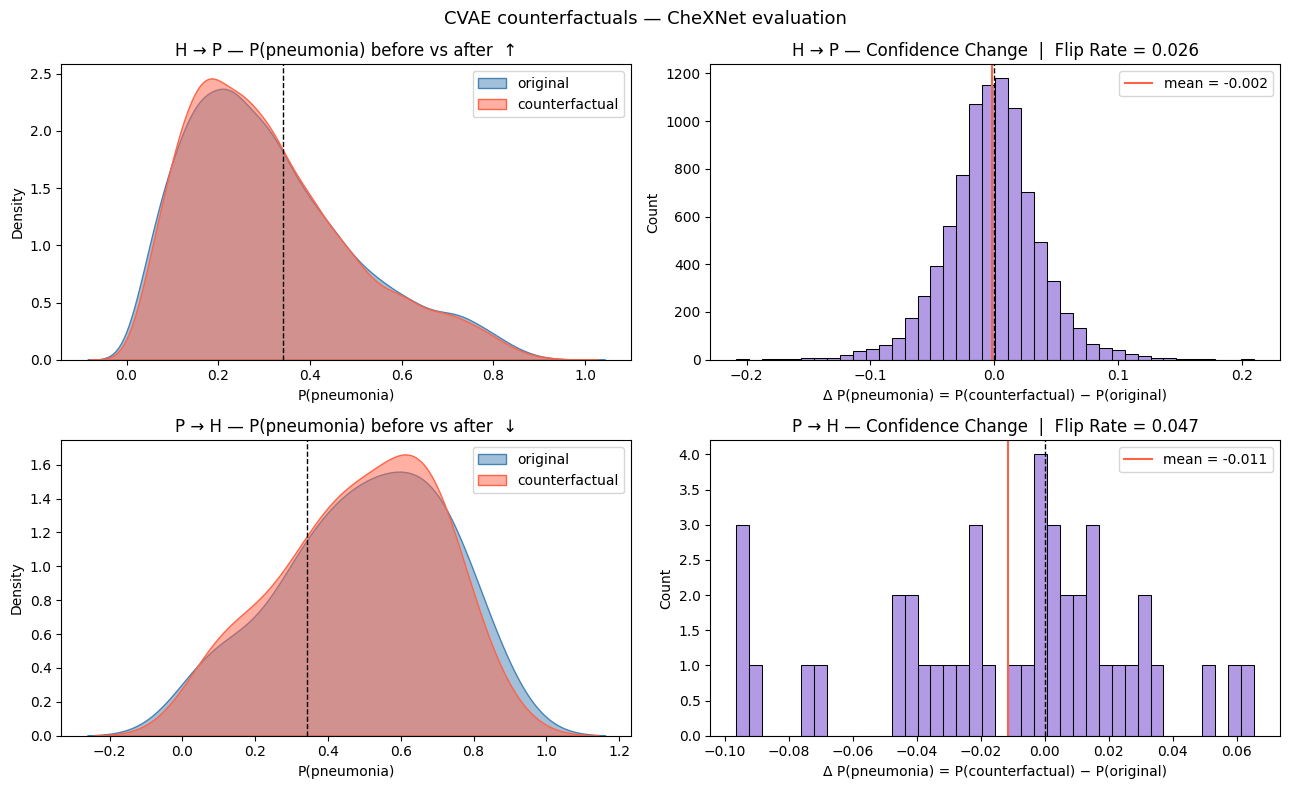

Saved to results/cvae_flip_rate.png


In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("CVAE counterfactuals — CheXNet evaluation", fontsize=13)

for row, (df, direction, expected) in enumerate([
    (h2p_df, "H → P", "↑"),
    (p2h_df, "P → H", "↓"),
]):
    ax = axes[row, 0]
    sns.kdeplot(df["p_original"],   ax=ax, fill=True, color="steelblue",
                alpha=0.5, label="original", common_norm=False)
    sns.kdeplot(df["p_translated"], ax=ax, fill=True, color="tomato",
                alpha=0.5, label="counterfactual", common_norm=False)
    ax.axvline(threshold, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("P(pneumonia)")
    ax.set_ylabel("Density")
    ax.set_title(f"{direction} — P(pneumonia) before vs after  {expected}")
    ax.legend()

    ax = axes[row, 1]
    sns.histplot(df["delta"], ax=ax, bins=40, color="mediumpurple", alpha=0.7)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axvline(df["delta"].mean(), color="tomato", linestyle="-", linewidth=1.5,
               label=f"mean = {df['delta'].mean():+.3f}")
    ax.set_xlabel("Δ P(pneumonia) = P(counterfactual) − P(original)")
    ax.set_ylabel("Count")
    ax.set_title(f"{direction} — Confidence Change  |  Flip Rate = {df['flip'].mean():.3f}")
    ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cvae_flip_rate.png", dpi=120)
plt.show()
print("Saved to results/cvae_flip_rate.png")

## 9. Save results

In [70]:
import json

h2p_df.to_csv(RESULTS_DIR / "cvae_h2p_scores.csv", index=False)
p2h_df.to_csv(RESULTS_DIR / "cvae_p2h_scores.csv", index=False)

summary = {
    "model": "CVAE",
    "healthy_to_pneumonia": {
        "n_pairs"   : len(h2p_df),
        "flip_rate" : round(h2p_df["flip"].mean(), 4),
        "delta_mean": round(h2p_df["delta"].mean(), 4),
        "delta_std" : round(h2p_df["delta"].std(),  4),
    },
    "pneumonia_to_healthy": {
        "n_pairs"   : len(p2h_df),
        "flip_rate" : round(p2h_df["flip"].mean(), 4),
        "delta_mean": round(p2h_df["delta"].mean(), 4),
        "delta_std" : round(p2h_df["delta"].std(),  4),
    },
}

with open(RESULTS_DIR / "cvae_flip_rate.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "model": "CVAE",
  "healthy_to_pneumonia": {
    "n_pairs": 8978,
    "flip_rate": 0.0257,
    "delta_mean": -0.0017,
    "delta_std": 0.0373
  },
  "pneumonia_to_healthy": {
    "n_pairs": 43,
    "flip_rate": 0.0465,
    "delta_mean": -0.0115,
    "delta_std": 0.0411
  }
}
